# End-to-End ML Pipeline: Tesla Deliveries

Dataset: `tesla_deliveries_dataset_2015_2025.csv`

Target variable: `Estimated_Deliveries`

This notebook covers data loading, initial inspection, EDA, preprocessing, feature engineering, regression modeling, hyperparameter tuning, cross-validation, feature importance, time-series forecasting, and final interpretation.

## 1. Data Loading & Initial Inspection


In [1]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, KFold, RandomizedSearchCV, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

try:
    from xgboost import XGBRegressor
    XGB_OK = True
except Exception as exc:
    XGBRegressor = None
    XGB_OK = False
    print('XGBoost unavailable:', exc)

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
RANDOM_STATE = 42
TARGET = 'Estimated_Deliveries'

csv_path = Path('tesla_deliveries_dataset_2015_2025.csv')
if not csv_path.exists():
    csv_path = Path('week2/tesla_deliveries_dataset_2015_2025.csv')

df = pd.read_csv(csv_path)
print('CSV path:', csv_path)
print('Shape:', df.shape)
display(df.head())
print('Column types:')
display(df.dtypes)
print('Missing values:')
display(df.isnull().sum())
print('Summary statistics:')
display(df.describe())


CSV path: tesla_deliveries_dataset_2015_2025.csv
Shape: (2640, 12)


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


Column types:


Year                      int64
Month                     int64
Region                   object
Model                    object
Estimated_Deliveries      int64
Production_Units          int64
Avg_Price_USD           float64
Battery_Capacity_kWh      int64
Range_km                  int64
CO2_Saved_tons          float64
Source_Type              object
Charging_Stations         int64
dtype: object

Missing values:


Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

Summary statistics:


,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


## 2. Exploratory Data Analysis (EDA)


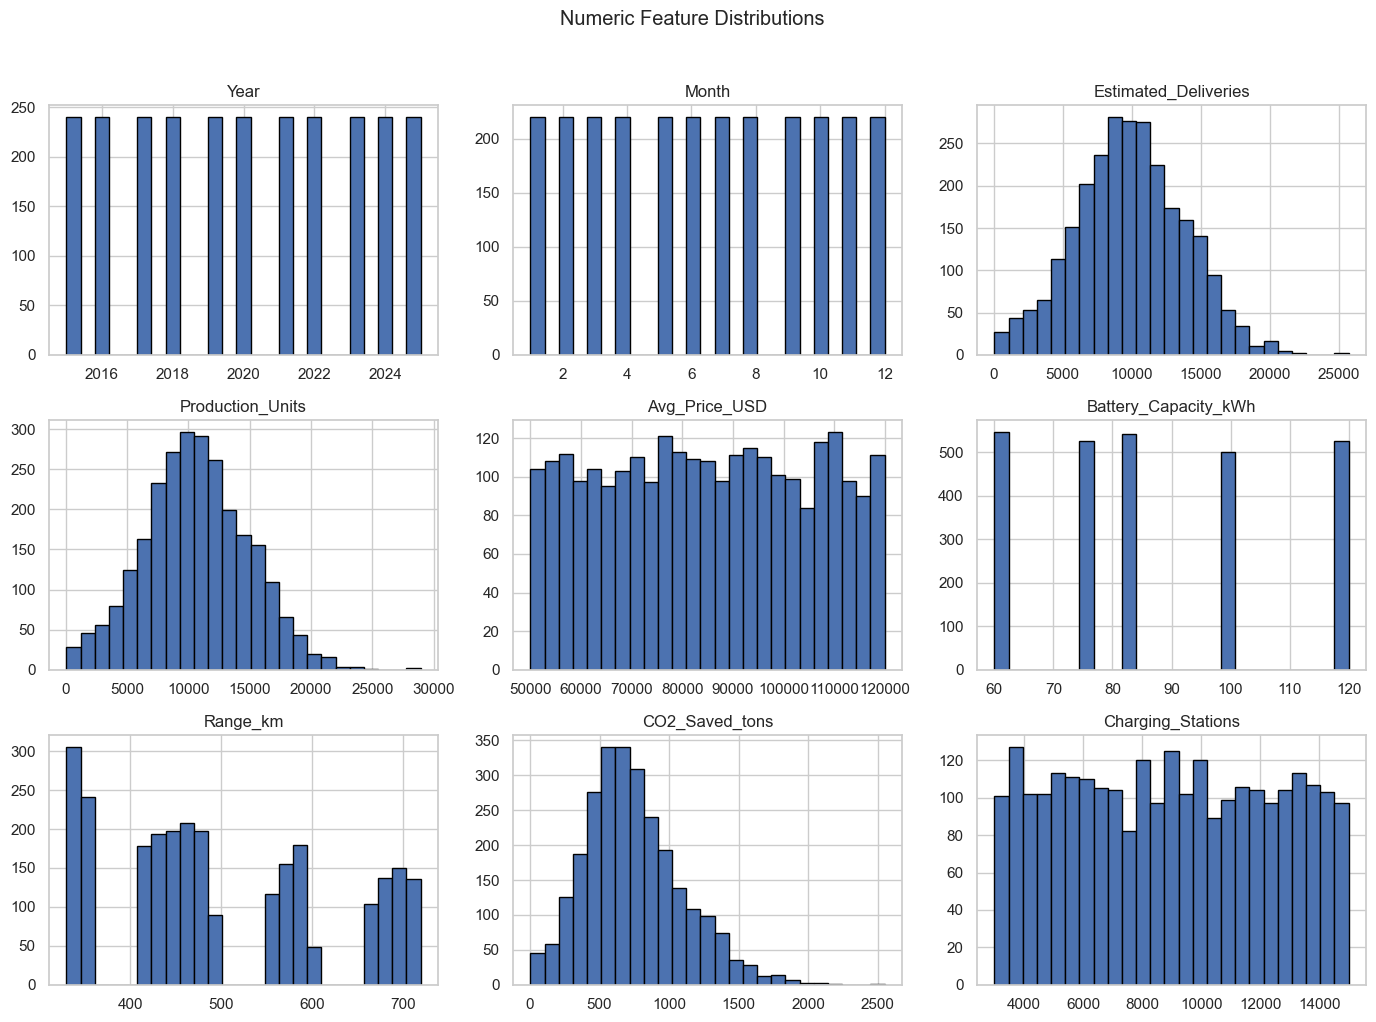

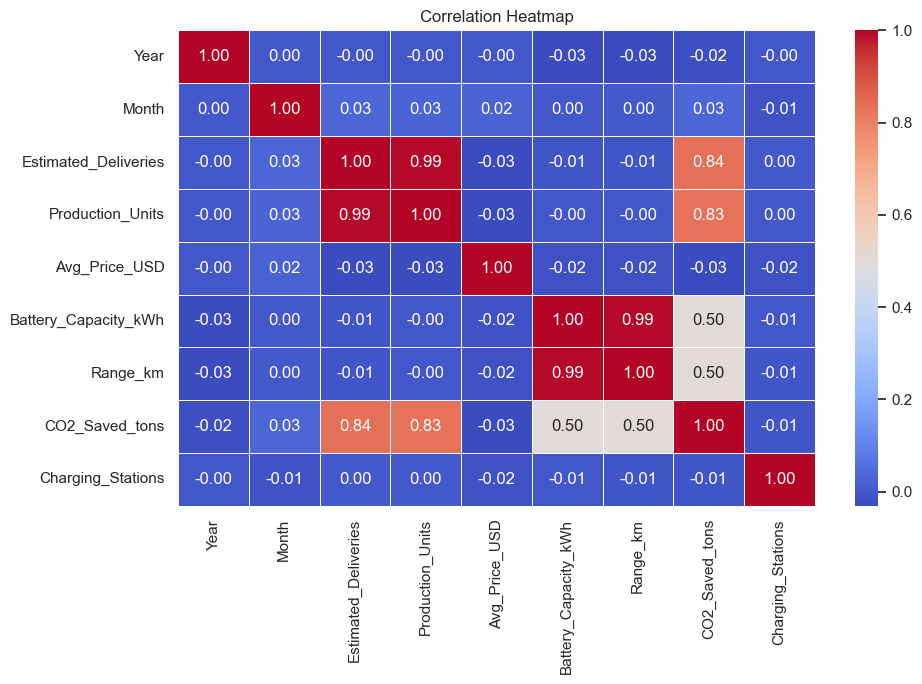

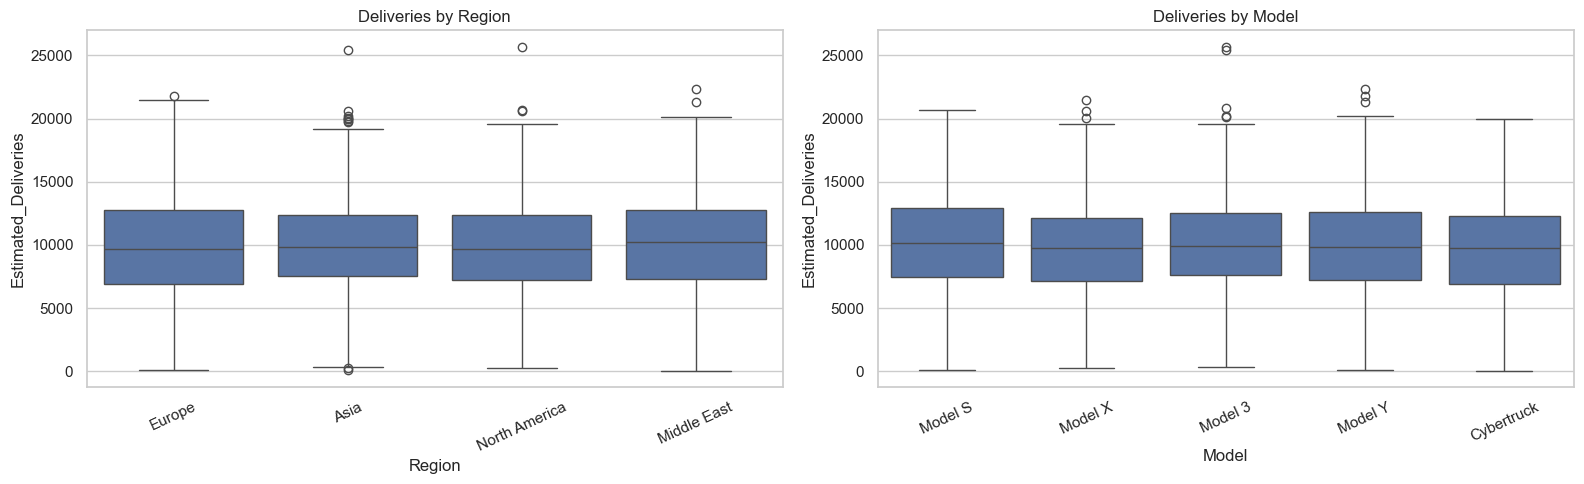

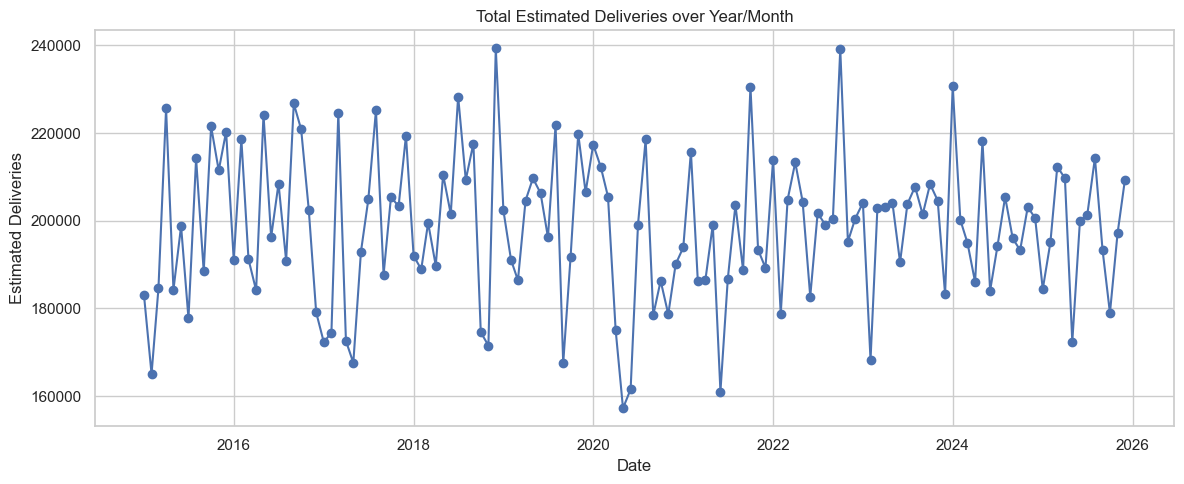

IQR bounds: -535.38 to 20337.62
IQR outliers: 12
Z-score outliers: 4


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
117,2022,11,Middle East,Model Y,21296,23581,57673.97,60,352,1124.43,Estimated (Region),4630
206,2022,10,Europe,Model 3,20841,23735,95174.19,60,342,1069.14,Official (Quarter),14164
281,2015,3,Asia,Model 3,25410,28802,73659.66,60,341,1299.72,Official (Quarter),4127
725,2015,6,Middle East,Model Y,22315,22673,81318.87,82,472,1579.90,Interpolated (Month),5909
729,2018,4,Europe,Model X,21473,24427,78461.34,60,334,1075.80,Interpolated (Month),11576


In [2]:
numeric_cols = df.select_dtypes(include=np.number).columns
df[numeric_cols].hist(bins=25, figsize=(14, 10), edgecolor='black')
plt.suptitle('Numeric Feature Distributions', y=1.02)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 7))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.boxplot(data=df, x='Region', y=TARGET, ax=axes[0])
axes[0].set_title('Deliveries by Region')
axes[0].tick_params(axis='x', rotation=25)
sns.boxplot(data=df, x='Model', y=TARGET, ax=axes[1])
axes[1].set_title('Deliveries by Model')
axes[1].tick_params(axis='x', rotation=25)
plt.tight_layout()
plt.show()

monthly = (df.groupby(['Year', 'Month'], as_index=False)[TARGET]
             .sum()
             .sort_values(['Year', 'Month']))
monthly['Date'] = pd.to_datetime(monthly['Year'].astype(str) + '-' + monthly['Month'].astype(str) + '-01')
plt.figure(figsize=(12, 5))
plt.plot(monthly['Date'], monthly[TARGET], marker='o')
plt.title('Total Estimated Deliveries over Year/Month')
plt.xlabel('Date')
plt.ylabel('Estimated Deliveries')
plt.tight_layout()
plt.show()

q1, q3 = df[TARGET].quantile([0.25, 0.75])
iqr = q3 - q1
lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
iqr_outliers = df[(df[TARGET] < lower) | (df[TARGET] > upper)]
z_scores = (df[TARGET] - df[TARGET].mean()) / df[TARGET].std()
z_outliers = df[z_scores.abs() > 3]
print(f'IQR bounds: {lower:.2f} to {upper:.2f}')
print('IQR outliers:', len(iqr_outliers))
print('Z-score outliers:', len(z_outliers))
display(iqr_outliers.head())


## 3. Preprocessing


In [3]:
model_df = df.drop(columns=['Source_Type'], errors='ignore').copy()
X = model_df.drop(columns=[TARGET])
y = model_df[TARGET]

cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = X.select_dtypes(include=np.number).columns.tolist()
num_pipe = Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())])
cat_pipe = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('onehot', OneHotEncoder(handle_unknown='ignore'))])
preprocessor = ColumnTransformer([('num', num_pipe, num_cols), ('cat', cat_pipe, cat_cols)])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
print('Categorical columns:', cat_cols)
print('Numeric columns:', num_cols)
print('Train/test shapes:', X_train.shape, X_test.shape)


Categorical columns: ['Region', 'Model']
Numeric columns: ['Year', 'Month', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Charging_Stations']
Train/test shapes: (2112, 10) (528, 10)


## 4. Feature Engineering


In [4]:
def add_features(data):
    data = data.copy()
    data['Month_sin'] = np.sin(2 * np.pi * data['Month'] / 12)
    data['Month_cos'] = np.cos(2 * np.pi * data['Month'] / 12)
    data['Quarter'] = ((data['Month'] - 1) // 3) + 1
    data['kWh_per_km'] = data['Battery_Capacity_kWh'] / data['Range_km'].replace(0, np.nan)
    return data

featured = add_features(df).drop(columns=['Source_Type'], errors='ignore')
X_fe = featured.drop(columns=[TARGET])
y_log = np.log1p(featured[TARGET])
cat_fe = X_fe.select_dtypes(include=['object', 'category']).columns.tolist()
num_fe = X_fe.select_dtypes(include=np.number).columns.tolist()
preprocessor_fe = ColumnTransformer([('num', num_pipe, num_fe), ('cat', cat_pipe, cat_fe)])
X_train_fe, X_test_fe, y_train_log, y_test_log = train_test_split(X_fe, y_log, test_size=0.2, random_state=RANDOM_STATE)
print('Engineered numeric columns:', num_fe)
display(featured.head())


Engineered numeric columns: ['Year', 'Month', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Charging_Stations', 'Month_sin', 'Month_cos', 'Quarter', 'kWh_per_km']


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations,Month_sin,Month_cos,Quarter,kWh_per_km
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,12207,5.000000e-01,-0.866025,2,0.170455
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,7640,8.660254e-01,0.500000,1,0.171233
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,14071,5.000000e-01,0.866025,1,0.170833
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,9333,8.660254e-01,0.500000,1,0.168539
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,8722,-2.449294e-16,1.000000,4,0.181543


## 5. Regression Modeling


In [5]:
def rmse_value(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def metrics_from_log(y_true_log, y_pred_log):
    y_true = np.expm1(y_true_log)
    y_pred = np.clip(np.expm1(y_pred_log), 0, None)
    return {
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': rmse_value(y_true, y_pred),
        'R2': r2_score(y_true, y_pred),
        'MAPE': np.mean(np.abs((y_true - y_pred) / np.where(y_true == 0, np.nan, y_true))) * 100
    }

models = {
    'Ridge': Ridge(),
    'RandomForestRegressor': RandomForestRegressor(n_estimators=250, random_state=RANDOM_STATE, n_jobs=-1),
    'GradientBoostingRegressor': GradientBoostingRegressor(random_state=RANDOM_STATE)
}
if XGB_OK:
    models['XGBRegressor'] = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=4, subsample=0.9, objective='reg:squarederror', random_state=RANDOM_STATE, n_jobs=-1)

results, fitted = [], {}
for name, estimator in models.items():
    pipe = Pipeline([('preprocess', preprocessor_fe), ('model', estimator)])
    pipe.fit(X_train_fe, y_train_log)
    pred_log = pipe.predict(X_test_fe)
    row = metrics_from_log(y_test_log, pred_log)
    row['Model'] = name
    results.append(row)
    fitted[name] = pipe

results_df = pd.DataFrame(results).set_index('Model').sort_values('RMSE')
display(results_df)


,MAE,RMSE,R2,MAPE
Model,,,,
XGBRegressor,305.873296,378.913524,0.990368,3.239293
GradientBoostingRegressor,327.379654,405.154086,0.988988,3.418257
RandomForestRegressor,329.712467,417.559602,0.988303,3.436652
Ridge,1263.279004,1916.168961,0.753681,14.914902


## 6. Hyperparameter Tuning


In [6]:
rf_pipe = Pipeline([('preprocess', preprocessor_fe), ('model', RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1))])
rf_grid = {
    'model__n_estimators': [150, 250],
    'model__max_depth': [None, 8, 14],
    'model__min_samples_split': [2, 5]
}
rf_search = GridSearchCV(rf_pipe, rf_grid, cv=3, scoring='r2', n_jobs=-1)
rf_search.fit(X_train_fe, y_train_log)
print('Best RF params:', rf_search.best_params_)
print('Best RF CV R2:', round(rf_search.best_score_, 4))

xgb_search = None
if XGB_OK:
    xgb_pipe = Pipeline([('preprocess', preprocessor_fe), ('model', XGBRegressor(objective='reg:squarederror', random_state=RANDOM_STATE, n_jobs=-1))])
    xgb_params = {
        'model__n_estimators': [150, 250, 350],
        'model__learning_rate': [0.03, 0.05, 0.08],
        'model__max_depth': [3, 4, 5],
        'model__subsample': [0.8, 0.9, 1.0]
    }
    xgb_search = RandomizedSearchCV(xgb_pipe, xgb_params, n_iter=12, cv=3, scoring='r2', random_state=RANDOM_STATE, n_jobs=-1)
    xgb_search.fit(X_train_fe, y_train_log)
    print('Best XGB params:', xgb_search.best_params_)
    print('Best XGB CV R2:', round(xgb_search.best_score_, 4))
else:
    print('Install xgboost to run XGBRegressor tuning.')


Best RF params: {'model__max_depth': 14, 'model__min_samples_split': 2, 'model__n_estimators': 150}
Best RF CV R2: 0.9908


Best XGB params: {'model__subsample': 0.9, 'model__n_estimators': 250, 'model__max_depth': 5, 'model__learning_rate': 0.05}
Best XGB CV R2: 0.9859


## 7. Cross-Validation


In [7]:
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_rows = []
for name, estimator in models.items():
    pipe = Pipeline([('preprocess', preprocessor_fe), ('model', estimator)])
    scores = cross_val_score(pipe, X_fe, y_log, cv=kf, scoring='r2', n_jobs=-1)
    cv_rows.append({'Model': name, 'Mean R2': scores.mean(), 'Std R2': scores.std()})
cv_df = pd.DataFrame(cv_rows).set_index('Model').sort_values('Mean R2', ascending=False)
display(cv_df)
for model, row in cv_df.iterrows():
    print(f'{model}: {row["Mean R2"]:.4f} +/- {row["Std R2"]:.4f}')


,Mean R2,Std R2
Model,,
GradientBoostingRegressor,0.993901,0.001040
RandomForestRegressor,0.991894,0.004027
XGBRegressor,0.985739,0.011084
Ridge,0.784865,0.042594


GradientBoostingRegressor: 0.9939 +/- 0.0010
RandomForestRegressor: 0.9919 +/- 0.0040
XGBRegressor: 0.9857 +/- 0.0111
Ridge: 0.7849 +/- 0.0426


## 8. Feature Importance


Feature-importance model: XGBRegressor


,Feature,Importance
2,Production_Units,0.926083
15,Region_North America,0.014138
16,Model_Cybertruck,0.012494
14,Region_Middle East,0.011347
6,CO2_Saved_tons,0.007647
19,Model_Model X,0.006167
7,Charging_Stations,0.003985
5,Range_km,0.002786
4,Battery_Capacity_kWh,0.002440
0,Year,0.002113


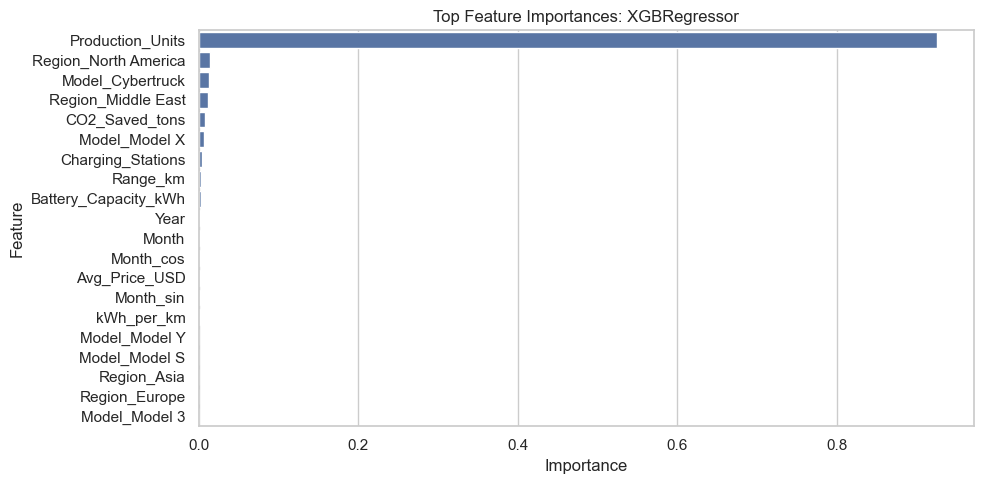

Low-importance original numeric features: ['Year', 'Month', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'Charging_Stations', 'Month_sin', 'Month_cos', 'Quarter', 'kWh_per_km']


,MAE,RMSE,R2,MAPE
Reduced feature model,336.059907,421.709644,0.98807,3.556272


In [8]:
def feature_names_from_preprocessor(preprocessor):
    names = []
    for name, transformer, cols in preprocessor.transformers_:
        if name == 'num':
            names.extend(cols)
        elif name == 'cat':
            names.extend(transformer.named_steps['onehot'].get_feature_names_out(cols))
    return np.array(names)

tree_candidates = [m for m in results_df.index if hasattr(fitted[m].named_steps['model'], 'feature_importances_')]
importance_model_name = tree_candidates[0] if tree_candidates else None
importance_df = pd.DataFrame()
if importance_model_name:
    importance_pipe = fitted[importance_model_name]
    importance_df = pd.DataFrame({
        'Feature': feature_names_from_preprocessor(importance_pipe.named_steps['preprocess']),
        'Importance': importance_pipe.named_steps['model'].feature_importances_
    }).sort_values('Importance', ascending=False)
    print('Feature-importance model:', importance_model_name)
    display(importance_df.head(20))
    sns.barplot(data=importance_df.head(20), y='Feature', x='Importance')
    plt.title(f'Top Feature Importances: {importance_model_name}')
    plt.tight_layout()
    plt.show()
else:
    print('No fitted tree model exposes feature_importances_.')

if not importance_df.empty:
    low_original = [f for f in num_fe if f in importance_df.query('Importance < 0.005')['Feature'].tolist()]
    print('Low-importance original numeric features:', low_original)
    if low_original:
        X_reduced = X_fe.drop(columns=low_original)
        cat_red = X_reduced.select_dtypes(include=['object', 'category']).columns.tolist()
        num_red = X_reduced.select_dtypes(include=np.number).columns.tolist()
        pre_red = ColumnTransformer([('num', num_pipe, num_red), ('cat', cat_pipe, cat_red)])
        Xtr, Xte, ytr, yte = train_test_split(X_reduced, y_log, test_size=0.2, random_state=RANDOM_STATE)
        reduced = Pipeline([('preprocess', pre_red), ('model', clone(importance_pipe.named_steps['model']))])
        reduced.fit(Xtr, ytr)
        display(pd.DataFrame([metrics_from_log(yte, reduced.predict(Xte))], index=['Reduced feature model']))
    else:
        print('No original numeric feature fell below the importance threshold.')


## 9. Time Series Forecasting


,MAE,RMSE,R2,MAPE
Time-series forecast,11011.75,14391.771538,-0.265357,5.589744


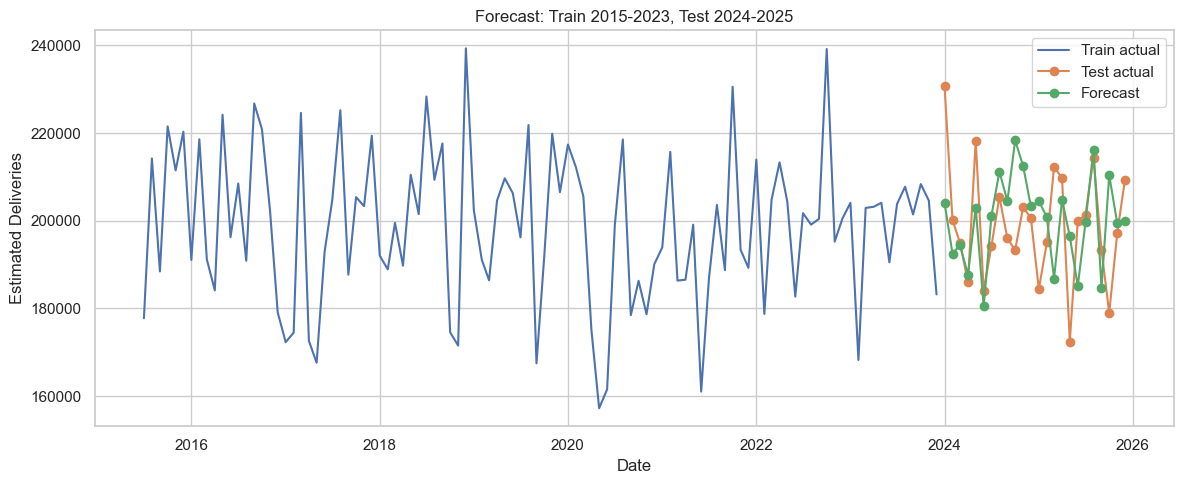

In [9]:
ts = (df.groupby(['Year', 'Month'], as_index=False)[TARGET].sum().sort_values(['Year', 'Month']))
ts['Date'] = pd.to_datetime(ts['Year'].astype(str) + '-' + ts['Month'].astype(str) + '-01')
ts['lag_1'] = ts[TARGET].shift(1)
ts['lag_2'] = ts[TARGET].shift(2)
ts['lag_3'] = ts[TARGET].shift(3)
ts['rolling_3'] = ts[TARGET].shift(1).rolling(3).mean()
ts['rolling_6'] = ts[TARGET].shift(1).rolling(6).mean()
ts['Month_sin'] = np.sin(2 * np.pi * ts['Month'] / 12)
ts['Month_cos'] = np.cos(2 * np.pi * ts['Month'] / 12)
ts['Quarter'] = ((ts['Month'] - 1) // 3) + 1
ts = ts.dropna()

train_ts = ts[ts['Year'] <= 2023]
test_ts = ts[ts['Year'] >= 2024]
ts_features = ['Year', 'Month', 'Quarter', 'Month_sin', 'Month_cos', 'lag_1', 'lag_2', 'lag_3', 'rolling_3', 'rolling_6']
forecast_model = XGBRegressor(n_estimators=250, learning_rate=0.05, max_depth=3, subsample=0.9, objective='reg:squarederror', random_state=RANDOM_STATE, n_jobs=-1) if XGB_OK else GradientBoostingRegressor(random_state=RANDOM_STATE)
forecast_model.fit(train_ts[ts_features], train_ts[TARGET])
ts_pred = forecast_model.predict(test_ts[ts_features])
ts_metrics = {
    'MAE': mean_absolute_error(test_ts[TARGET], ts_pred),
    'RMSE': rmse_value(test_ts[TARGET], ts_pred),
    'R2': r2_score(test_ts[TARGET], ts_pred),
    'MAPE': np.mean(np.abs((test_ts[TARGET] - ts_pred) / test_ts[TARGET])) * 100
}
display(pd.DataFrame([ts_metrics], index=['Time-series forecast']))
plt.figure(figsize=(12, 5))
plt.plot(train_ts['Date'], train_ts[TARGET], label='Train actual')
plt.plot(test_ts['Date'], test_ts[TARGET], marker='o', label='Test actual')
plt.plot(test_ts['Date'], ts_pred, marker='o', label='Forecast')
plt.title('Forecast: Train 2015-2023, Test 2024-2025')
plt.xlabel('Date')
plt.ylabel('Estimated Deliveries')
plt.legend()
plt.tight_layout()
plt.show()


## 10. Results & Interpretation


,MAE,RMSE,R2,MAPE
Model,,,,
XGBRegressor Tuned,291.033054,363.242916,0.991148,3.083619
XGBRegressor,305.873296,378.913524,0.990368,3.239293
GradientBoostingRegressor,327.379654,405.154086,0.988988,3.418257
RandomForest Tuned,329.780853,417.233278,0.988321,3.438388
RandomForestRegressor,329.712467,417.559602,0.988303,3.436652
Ridge,1263.279004,1916.168961,0.753681,14.914902


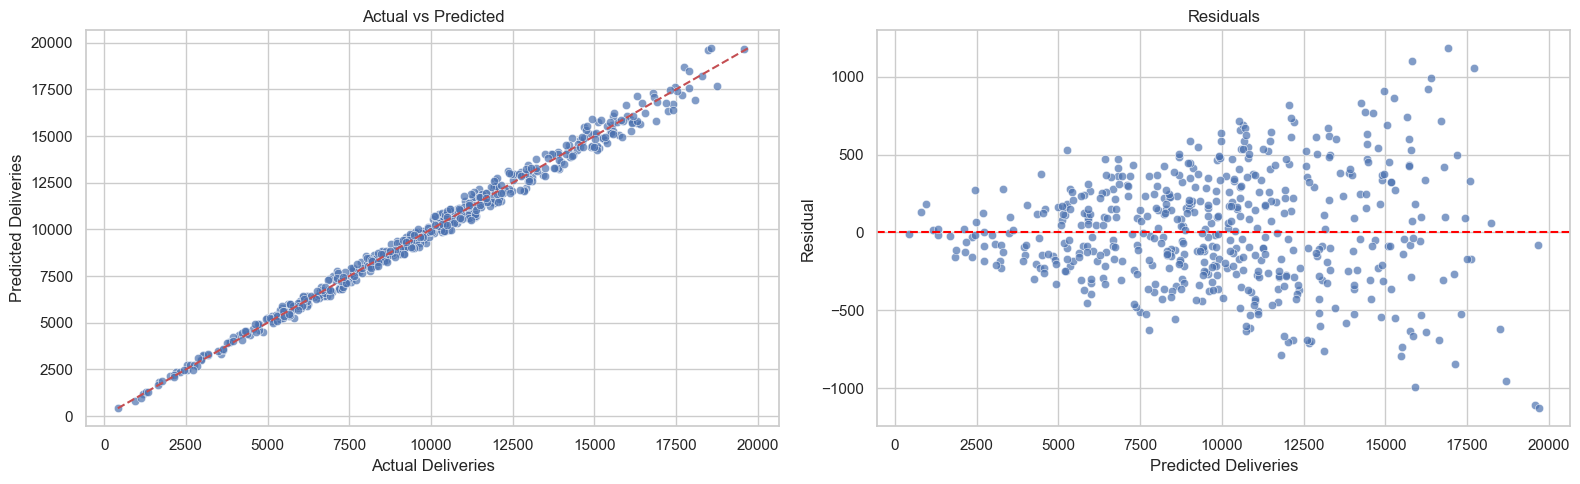

Best model: XGBRegressor Tuned
Reason: it has the lowest holdout RMSE while maintaining strong R2, so it gives the smallest typical prediction error on unseen rows.
Tree models are strong candidates here because delivery volume can depend on nonlinear interactions among region, model, production, price, battery/range, charging stations, and seasonality.


In [10]:
summary = results_df.copy()
summary.loc['RandomForest Tuned'] = metrics_from_log(y_test_log, rf_search.predict(X_test_fe))
if xgb_search is not None:
    summary.loc['XGBRegressor Tuned'] = metrics_from_log(y_test_log, xgb_search.predict(X_test_fe))
summary = summary.sort_values('RMSE')
display(summary)

final_name = summary.index[0]
if final_name == 'RandomForest Tuned':
    final_model = rf_search.best_estimator_
elif final_name == 'XGBRegressor Tuned' and xgb_search is not None:
    final_model = xgb_search.best_estimator_
else:
    final_model = fitted[final_name]

actual = np.expm1(y_test_log)
pred = np.clip(np.expm1(final_model.predict(X_test_fe)), 0, None)
resid = actual - pred

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.scatterplot(x=actual, y=pred, ax=axes[0], alpha=0.7)
lo, hi = min(actual.min(), pred.min()), max(actual.max(), pred.max())
axes[0].plot([lo, hi], [lo, hi], 'r--')
axes[0].set_title('Actual vs Predicted')
axes[0].set_xlabel('Actual Deliveries')
axes[0].set_ylabel('Predicted Deliveries')
sns.scatterplot(x=pred, y=resid, ax=axes[1], alpha=0.7)
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_title('Residuals')
axes[1].set_xlabel('Predicted Deliveries')
axes[1].set_ylabel('Residual')
plt.tight_layout()
plt.show()

print(f'Best model: {final_name}')
print('Reason: it has the lowest holdout RMSE while maintaining strong R2, so it gives the smallest typical prediction error on unseen rows.')
print('Tree models are strong candidates here because delivery volume can depend on nonlinear interactions among region, model, production, price, battery/range, charging stations, and seasonality.')